# 데이터 전처리

In [577]:
import pandas as pd

In [578]:
df = pd.read_csv("/Users/leehyunsong/Desktop/실전 프로젝트/Courses.csv")

df['course name'] = df['course_id'].replace({
    "HarvardX/CB22x/2013_Spring": "The Ancient Greek Hero",
    "HarvardX/CS50x/2012": "Introduction to Computer Science",
    "HarvardX/ER22x/2013_Spring": "Justice",
    "HarvardX/PH207x/2012_Fall": "Health in Numbers: Quantitative Methods in Clinical & Public Health Research",
    "HarvardX/PH278x/2013_Spring": "Human Health and Global Environmental Change",
    "MITx/6.002x/2012_Fall": "Circuits and Electronics_f",
    "MITx/6.002x/2013_Spring": "Circuits and Electronics_s",
    "MITx/14.73x/2013_Spring": "The Challenges of Global Poverty",
    "MITx/2.01x/2013_Spring": "Elements of Structures",
    "MITx/3.091x/2012_Fall": "Introduction to Solid State Chemistry_f",
    "MITx/3.091x/2013_Spring": "Introduction to Solid State Chemistry_s",
    "MITx/6.00x/2012_Fall": "Introduction to Computer Science and Programming_f",
    "MITx/6.00x/2013_Spring": "Introduction to Computer Science and Programming_s",
    "MITx/7.00x/2013_Spring": "Introduction to Biology - The Secret of Life",
    "MITx/8.02x/2013_Spring": "Physics II: Electricity and Magnetism",
    "MITx/8.MReV/2013_Summer": "Mechanics ReView"
})

# 컬럼명 소문자로 변환 + 일부 이름 정리
# df.columns = [col.lower() for col in df.columns]
# df.rename(columns={
#     'userid_di': 'user_id',
#     'final_cc_cname_di': 'country',
#     'LoE_DI': 'education',
#     'start_time_di': 'start_time',
#     'last_event_di': 'last_event'
# }, inplace=True)

# 자료형 변환
df['grade'] = df['grade'].replace(" ", pd.NA)
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

# 'yob'는 숫자형으로 변환 ('Unknown' 등은 NaN으로 처리)
df['YoB'] = pd.to_numeric(df['YoB'], errors='coerce')

# 소수점 제거 → 정수형(Int64)으로 변환 (NaN 허용)
df['YoB'] = df['YoB'].astype('Int64')

df['ndays_act'] = pd.to_numeric(df['ndays_act'], errors='coerce')


# 날짜형 컬럼 변환
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'], errors='coerce')
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'], errors='coerce')

# 칼럼 제거
df = df.drop(['nplay_video', 'roles', 'registered', 'index', 'incomplete_flag'], axis=1) #, inplace=True)

# 결측값 제거
df.dropna(subset=['last_event_DI'], inplace = True)

# 결측치 처리
df['LoE_DI'] = df['LoE_DI'].fillna('Unknown')
df['gender'] = df['gender'].fillna('o')
df['grade'] = df['grade'].fillna(0)
df['ndays_act'] = df['ndays_act'].fillna(0)
df['nchapters'] = df['nchapters'].fillna(0)
df['nevents'] = df['nevents'].fillna(0)


# 이상치 처리
df = df[df['YoB'] < 2005] # 2005년 이전 출생자만 조회(미취학 아동)


# 파생변수 
df['study_time'] = df['last_event_DI'] - df['start_time_DI'] + pd.Timedelta(days = 1)
# 이상치 처리
df = df[df['study_time'] > pd.Timedelta(0)]

# 지금 현상태의 문제점: 가입해서 딱 하루 공부한 사람이 집중 오진다.
-> 그럼 study_time = 1이고, 수료한 사람만 체킹?
-> study_time에 상한, 하한을 두자

In [579]:
df[['start_time_DI','last_event_DI','study_time', 'ndays_act']].sort_values(by = 'ndays_act', ascending= False)

,start_time_DI,last_event_DI,study_time,ndays_act
460957,2012-09-30,2013-08-25,330 days,205.0
458885,2012-09-28,2013-05-16,231 days,162.0
399519,2012-08-14,2013-07-24,345 days,160.0
157091,2012-10-25,2013-05-14,202 days,159.0
435179,2012-09-08,2013-09-05,363 days,158.0
...,...,...,...,...
196292,2012-12-22,2013-11-17,331 days,0.0
236690,2013-02-05,2013-11-17,286 days,0.0
109456,2013-01-25,2013-11-17,297 days,0.0
196314,2012-12-22,2013-11-17,331 days,0.0


In [580]:
# 공부밀도 파생 변수
df['study_dense'] = df.apply(
    lambda row: 'x' if (row['study_time'] == pd.Timedelta(days = 1) and row['certified'] != 1) else row['ndays_act'] / row['study_time'].days 
    , axis=1
)

In [581]:
df[['start_time_DI','last_event_DI','study_time', 'ndays_act','study_dense']].sort_values(by = 'ndays_act', ascending= False)

,start_time_DI,last_event_DI,study_time,ndays_act,study_dense
460957,2012-09-30,2013-08-25,330 days,205.0,0.621212
458885,2012-09-28,2013-05-16,231 days,162.0,0.701299
399519,2012-08-14,2013-07-24,345 days,160.0,0.463768
157091,2012-10-25,2013-05-14,202 days,159.0,0.787129
435179,2012-09-08,2013-09-05,363 days,158.0,0.435262
...,...,...,...,...,...
196292,2012-12-22,2013-11-17,331 days,0.0,0.0
236690,2013-02-05,2013-11-17,286 days,0.0,0.0
109456,2013-01-25,2013-11-17,297 days,0.0,0.0
196314,2012-12-22,2013-11-17,331 days,0.0,0.0


In [582]:
# 공부밀도 파생 변수
df['study_dense'] = df['ndays_act'] / df['study_time'].dt.days

In [583]:
df['study_dense']

19332     0.008130
19334     0.051948
19335     0.004032
19348     0.005602
19350     0.060606
            ...   
641132    1.000000
641133    1.000000
641134    1.000000
641135    1.000000
641136    1.000000
Name: study_dense, Length: 385155, dtype: float64

In [584]:
df_study = df[['study_time', 'ndays_act', 'study_dense']].copy()
df_study


,study_time,ndays_act,study_dense
19332,369 days,3.0,0.008130
19334,154 days,8.0,0.051948
19335,248 days,1.0,0.004032
19348,357 days,2.0,0.005602
19350,33 days,2.0,0.060606
...,...,...,...
641132,1 days,1.0,1.000000
641133,1 days,1.0,1.000000
641134,1 days,1.0,1.000000
641135,1 days,1.0,1.000000


In [585]:
df_study[(df_study['study_time'].dt.days < df_study['ndays_act']) & (df_study['study_time']> pd.Timedelta(0))]

,study_time,ndays_act,study_dense
19356,4 days,13.0,3.25
19430,1 days,2.0,2.00
19558,1 days,5.0,5.00
19709,1 days,4.0,4.00
19839,1 days,4.0,4.00
...,...,...,...
635603,1 days,3.0,3.00
635960,1 days,2.0,2.00
636010,1 days,2.0,2.00
636260,1 days,2.0,2.00


In [586]:
df[['study_time', 'ndays_act', 'study_dense']]  

,study_time,ndays_act,study_dense
19332,369 days,3.0,0.008130
19334,154 days,8.0,0.051948
19335,248 days,1.0,0.004032
19348,357 days,2.0,0.005602
19350,33 days,2.0,0.060606
...,...,...,...
641132,1 days,1.0,1.000000
641133,1 days,1.0,1.000000
641134,1 days,1.0,1.000000
641135,1 days,1.0,1.000000


In [587]:
df.isnull().sum()

course_id            0
userid_DI            0
viewed               0
explored             0
certified            0
final_cc_cname_DI    0
LoE_DI               0
YoB                  0
gender               0
grade                0
start_time_DI        0
last_event_DI        0
nevents              0
ndays_act            0
nchapters            0
nforum_posts         0
course name          0
study_time           0
study_dense          0
dtype: int64

In [588]:
df.shape

(385155, 19)

In [589]:
# 컬럼명 소문자로 변환 + 일부 이름 정리
df.columns = [col.lower() for col in df.columns]
df.rename(columns={
  'userid_di': 'user_id',
  'final_cc_cname_di': 'country',
  'LoE_DI': 'education',
  'start_time_di': 'start_time',
  'last_event_di': 'last_event'}, inplace=True)

In [590]:
df.isnull().sum()

course_id       0
user_id         0
viewed          0
explored        0
certified       0
country         0
loe_di          0
yob             0
gender          0
grade           0
start_time      0
last_event      0
nevents         0
ndays_act       0
nchapters       0
nforum_posts    0
course name     0
study_time      0
study_dense     0
dtype: int64

# 강의 별 분석

In [591]:
df['course_id'].nunique()

16

In [592]:
df['course name'].nunique()

16

In [593]:
# 필수 라이브러리 설치
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform
from matplotlib import rc

system = platform.system()
if system == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
elif system == 'Windows':  # Windows
    rc('font', family='Malgun Gothic')
else:  # Linux (Colab 등)
    rc('font', family='NanumGothic')  # Colab은 보통 나눔고딕 설치 필요

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [594]:
df.head(0).T

""
course_id
user_id
viewed
explored
certified
country
loe_di
yob
gender
grade


## 강의 별 성별 차이

In [595]:
course_gender = df.pivot_table(index='course name', columns='gender', aggfunc='size', fill_value = 0)
course_gender

gender,f,m,o
course name,,,
Circuits and Electronics_f,2733,26098,0
Circuits and Electronics_s,1329,14019,0
Elements of Structures,224,3821,0
Health in Numbers: Quantitative Methods in Clinical & Public Health Research,14663,20027,0
Human Health and Global Environmental Change,11665,12077,0
Introduction to Biology - The Secret of Life,5607,9099,0
Introduction to Computer Science,6920,35990,1
Introduction to Computer Science and Programming_f,7546,44744,0
Introduction to Computer Science and Programming_s,6261,38523,0


In [596]:
course_gender_fm = course_gender[['f', 'm']].copy()
course_gender_fm = course_gender_fm.loc[(course_gender_fm['f'] + course_gender_fm['m']).sort_values(ascending=False).index]
course_gender_fm

gender,f,m
course name,,
Introduction to Computer Science and Programming_f,7546,44744
Introduction to Computer Science and Programming_s,6261,38523
Introduction to Computer Science,6920,35990
Justice,14132,22531
Health in Numbers: Quantitative Methods in Clinical & Public Health Research,14663,20027
Circuits and Electronics_f,2733,26098
The Ancient Greek Hero,11570,13920
Human Health and Global Environmental Change,11665,12077
The Challenges of Global Poverty,9827,11781


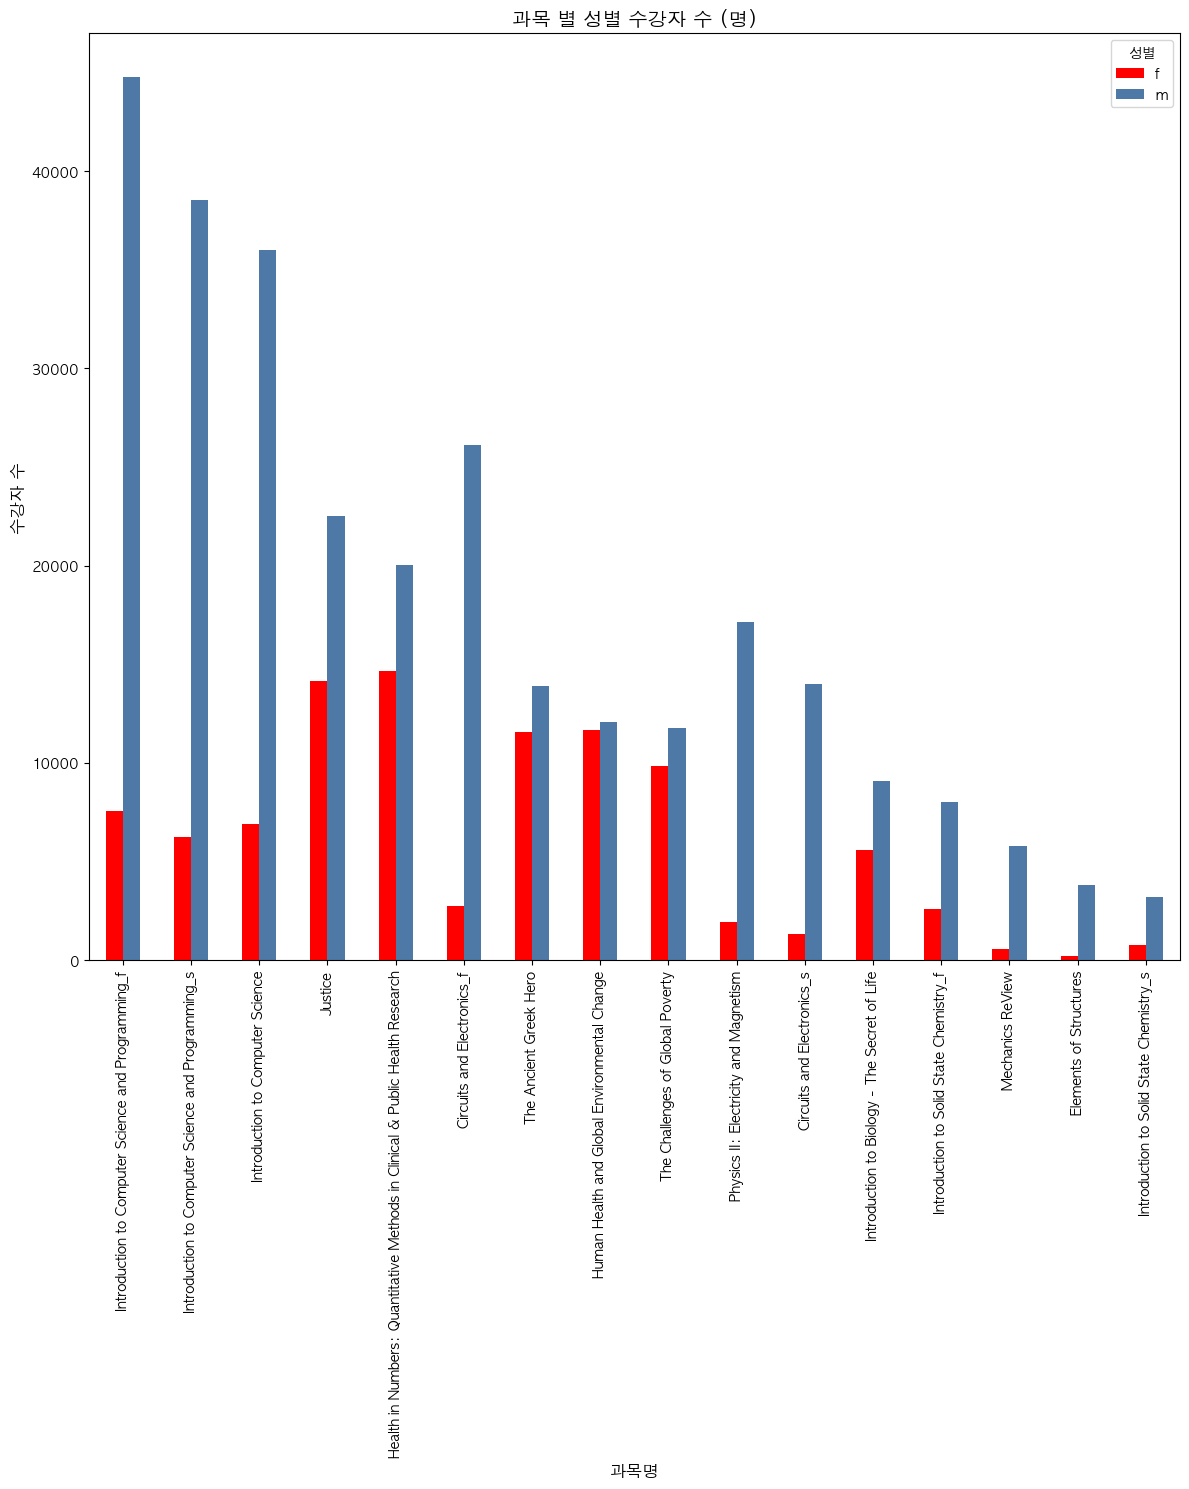

In [597]:
import matplotlib.pyplot as plt

course_gender_fm.plot(kind='bar', figsize=(12, 15), color=['#FF0000', '#4E79A7']) 
plt.title("과목 별 성별 수강자 수 (명)", fontsize=14)
plt.xlabel("과목명", fontsize=12)
plt.ylabel("수강자 수", fontsize=12)
plt.legend(title="성별")
plt.tight_layout()
plt.show()


## 과목 별 총 수강자

In [598]:
course_total = course_gender.copy()
course_total['total'] = course_total['f'] + course_total['m'] + course_total['o']
course_total = course_total.sort_values(by='total', ascending=False)
course_total

gender,f,m,o,total
course name,,,,
Introduction to Computer Science and Programming_f,7546,44744,0,52290
Introduction to Computer Science and Programming_s,6261,38523,0,44784
Introduction to Computer Science,6920,35990,1,42911
Justice,14132,22531,0,36663
Health in Numbers: Quantitative Methods in Clinical & Public Health Research,14663,20027,0,34690
Circuits and Electronics_f,2733,26098,0,28831
The Ancient Greek Hero,11570,13920,0,25490
Human Health and Global Environmental Change,11665,12077,0,23742
The Challenges of Global Poverty,9827,11781,0,21608


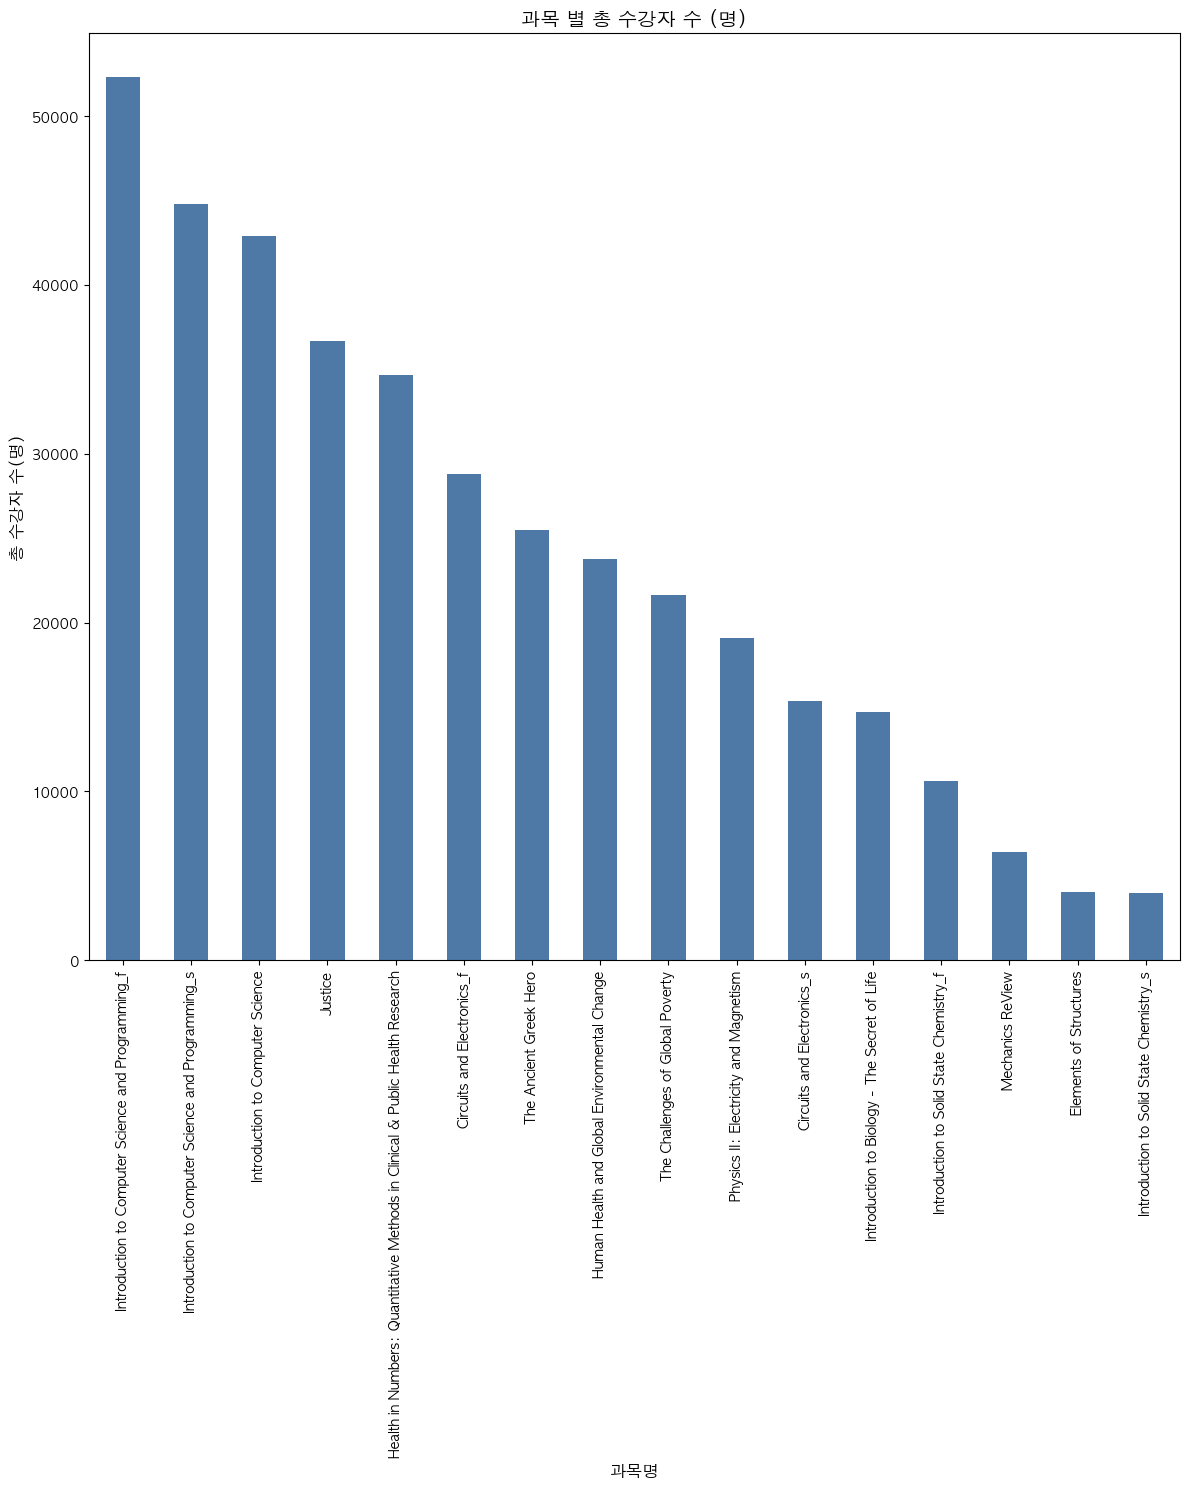

In [599]:
course_total['total'].plot(kind='bar', figsize=(12, 15), color=['#4E79A7']) 
plt.title("과목 별 총 수강자 수 (명)", fontsize=14)
plt.xlabel("과목명", fontsize=12)
plt.ylabel("총 수강자 수(명)", fontsize=12)
plt.tight_layout()
plt.show()


## 강의 별 학력 차이

In [600]:
course_education = df.pivot_table(index='course name', columns='loe_di', aggfunc='size', fill_value = 0)
course_education = course_education.loc[(course_gender_fm['f'] + course_gender_fm['m']).sort_values(ascending=False).index]
course_education

loe_di,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,Unknown
course name,,,,,,
Introduction to Computer Science and Programming_f,22139,680,1158,9375,16991,1947
Introduction to Computer Science and Programming_s,17867,618,1368,8130,15651,1150
Introduction to Computer Science,16123,503,1906,6752,16209,1418
Justice,14106,1193,943,9912,10063,446
Health in Numbers: Quantitative Methods in Clinical & Public Health Research,13343,2934,167,13405,4277,564
Circuits and Electronics_f,12726,271,423,3774,10634,1003
The Ancient Greek Hero,9753,1027,663,6710,6972,365
Human Health and Global Environmental Change,10009,600,373,6618,5853,289
The Challenges of Global Poverty,9659,533,172,7773,3391,80


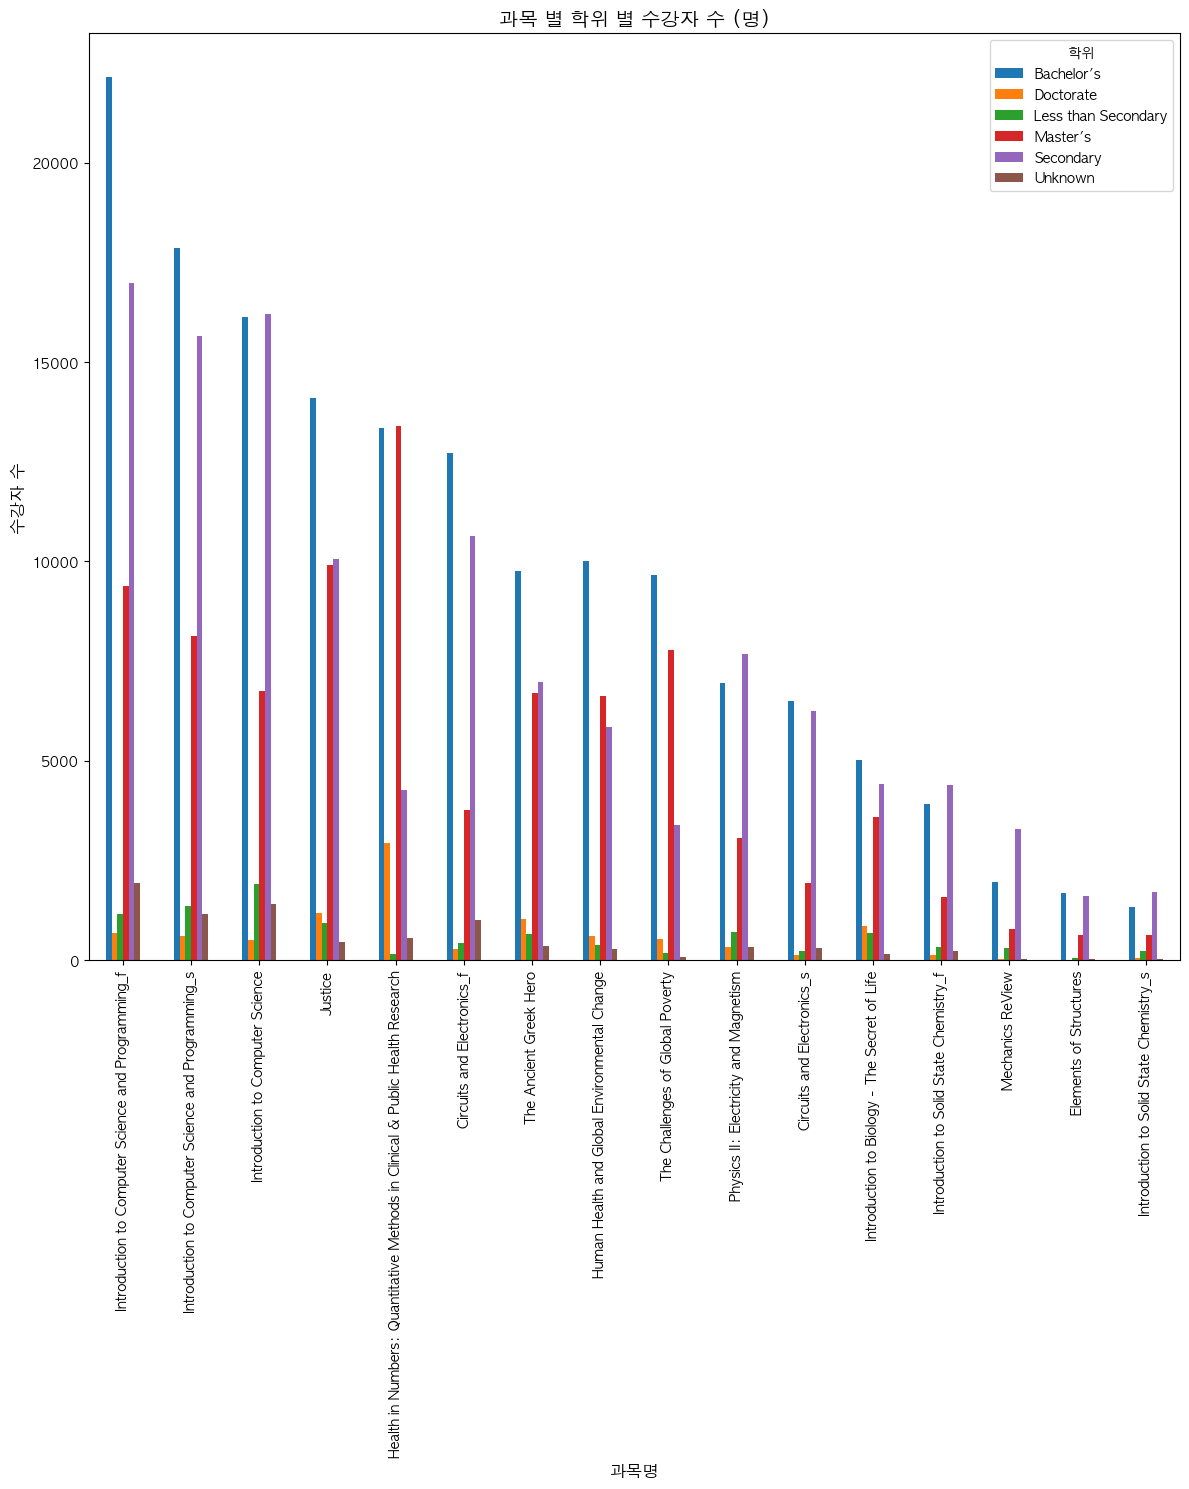

In [601]:
import matplotlib.pyplot as plt

course_education.plot(kind='bar', figsize=(12, 15)) 
plt.title("과목 별 학위 별 수강자 수 (명)", fontsize=14)
plt.xlabel("과목명", fontsize=12)
plt.ylabel("수강자 수", fontsize=12)
plt.legend(title="학위")
plt.tight_layout()
plt.show()


In [602]:
df['loe_di'].value_counts()

loe_di
Bachelor's             153109
Secondary              119399
Master's                84673
Doctorate                9881
Less than Secondary      9724
Unknown                  8369
Name: count, dtype: int64

In [603]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 385155 entries, 19332 to 641136
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype          
---  ------        --------------   -----          
 0   course_id     385155 non-null  object         
 1   user_id       385155 non-null  object         
 2   viewed        385155 non-null  int64          
 3   explored      385155 non-null  int64          
 4   certified     385155 non-null  int64          
 5   country       385155 non-null  object         
 6   loe_di        385155 non-null  object         
 7   yob           385155 non-null  Int64          
 8   gender        385155 non-null  object         
 9   grade         385155 non-null  float64        
 10  start_time    385155 non-null  datetime64[ns] 
 11  last_event    385155 non-null  datetime64[ns] 
 12  nevents       385155 non-null  float64        
 13  ndays_act     385155 non-null  float64        
 14  nchapters     385155 non-null  float64        
 15  n

In [604]:
cols = ['viewed', 'explored', 'certified', 'yob', 'grade', 'nevents', 'ndays_act', 'nchapters', 'nforum_posts', 'study_time', 'study_dense']
df_heat = df[cols].copy()
df_heat

,viewed,explored,certified,yob,grade,nevents,ndays_act,nchapters,nforum_posts,study_time,study_dense
19332,0,0,0,1989,0.0,6.0,3.0,0.0,0,369 days,0.008130
19334,1,0,0,1993,0.0,107.0,8.0,2.0,0,154 days,0.051948
19335,1,0,0,1988,0.0,8.0,1.0,1.0,0,248 days,0.004032
19348,1,0,0,1992,0.0,25.0,2.0,4.0,0,357 days,0.005602
19350,0,0,0,1980,0.0,3.0,2.0,0.0,0,33 days,0.060606
...,...,...,...,...,...,...,...,...,...,...,...
641132,1,0,0,1989,0.0,29.0,1.0,1.0,0,1 days,1.000000
641133,1,0,0,1991,0.0,97.0,1.0,2.0,0,1 days,1.000000
641134,0,0,0,1991,0.0,1.0,1.0,0.0,0,1 days,1.000000
641135,0,0,0,1979,0.0,1.0,1.0,0.0,0,1 days,1.000000


In [605]:
df_heat.corr()

,viewed,explored,certified,yob,grade,nevents,ndays_act,nchapters,nforum_posts,study_time,study_dense
viewed,1.000000,0.186038,0.124105,0.005085,0.158774,0.178754,0.238616,0.393338,0.062170,0.185458,-0.195670
explored,0.186038,1.000000,0.635307,-0.016552,0.700299,0.596566,0.676566,0.789449,0.091206,0.371271,-0.095176
certified,0.124105,0.635307,1.000000,0.000183,0.933185,0.636160,0.685060,0.625566,0.090721,0.270314,-0.063124
yob,0.005085,-0.016552,0.000183,1.000000,0.001096,-0.013351,-0.028916,-0.025426,0.031611,-0.030293,0.027448
grade,0.158774,0.700299,0.933185,0.001096,1.000000,0.700527,0.746971,0.692862,0.103813,0.302959,-0.079067
nevents,0.178754,0.596566,0.636160,-0.013351,0.700527,1.000000,0.843568,0.609050,0.122939,0.283809,-0.057746
ndays_act,0.238616,0.676566,0.685060,-0.028916,0.746971,0.843568,1.000000,0.714300,0.138880,0.395365,-0.096625
nchapters,0.393338,0.789449,0.625566,-0.025426,0.692862,0.609050,0.714300,1.000000,0.136741,0.384613,-0.151754
nforum_posts,0.062170,0.091206,0.090721,0.031611,0.103813,0.122939,0.138880,0.136741,1.000000,0.056382,-0.024197
study_time,0.185458,0.371271,0.270314,-0.030293,0.302959,0.283809,0.395365,0.384613,0.056382,1.000000,-0.419944


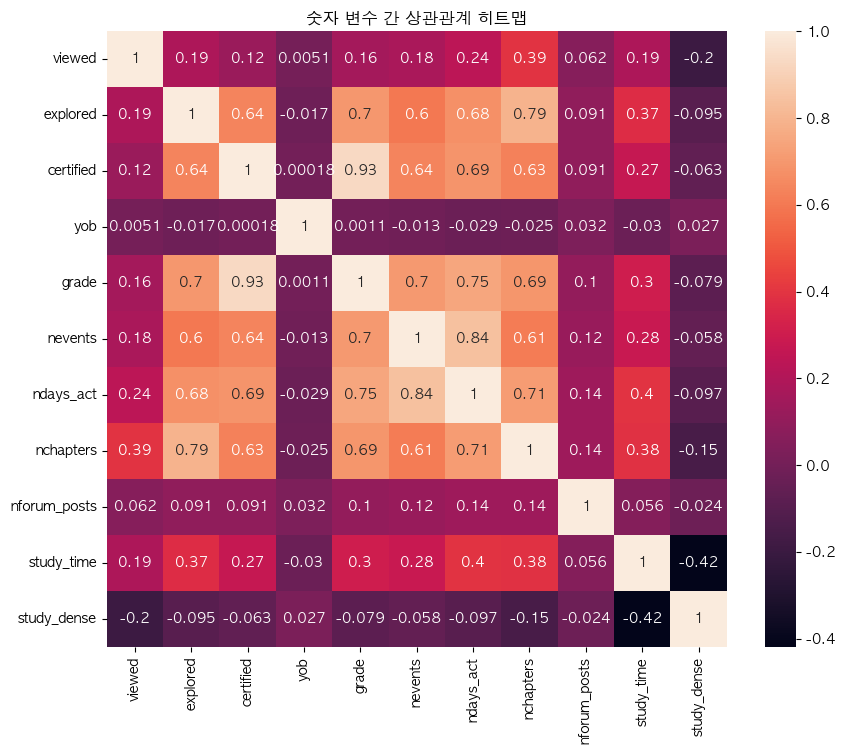

In [606]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df_heat.corr(), annot=True)
plt.title("숫자 변수 간 상관관계 히트맵")
plt.show()

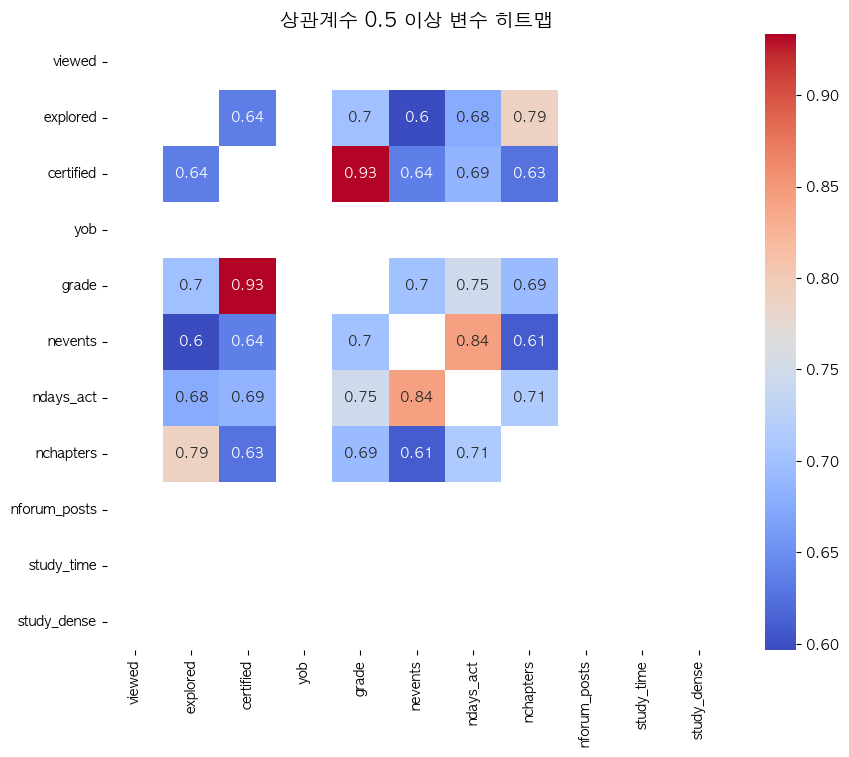

In [607]:
matrix = df_heat.corr()

high_corr = matrix[(abs(matrix) >= 0.5) & (matrix != 1.0)]

plt.figure(figsize=(10, 8))
sns.heatmap(high_corr, annot=True, cmap="coolwarm", mask=high_corr.isnull())
plt.title("상관계수 0.5 이상 변수 히트맵", fontsize=14)
plt.show()

In [608]:
high_corr_certifed = high_corr['certified'].sort_values(ascending=False)
high_corr_certifed = high_corr_certifed.dropna()

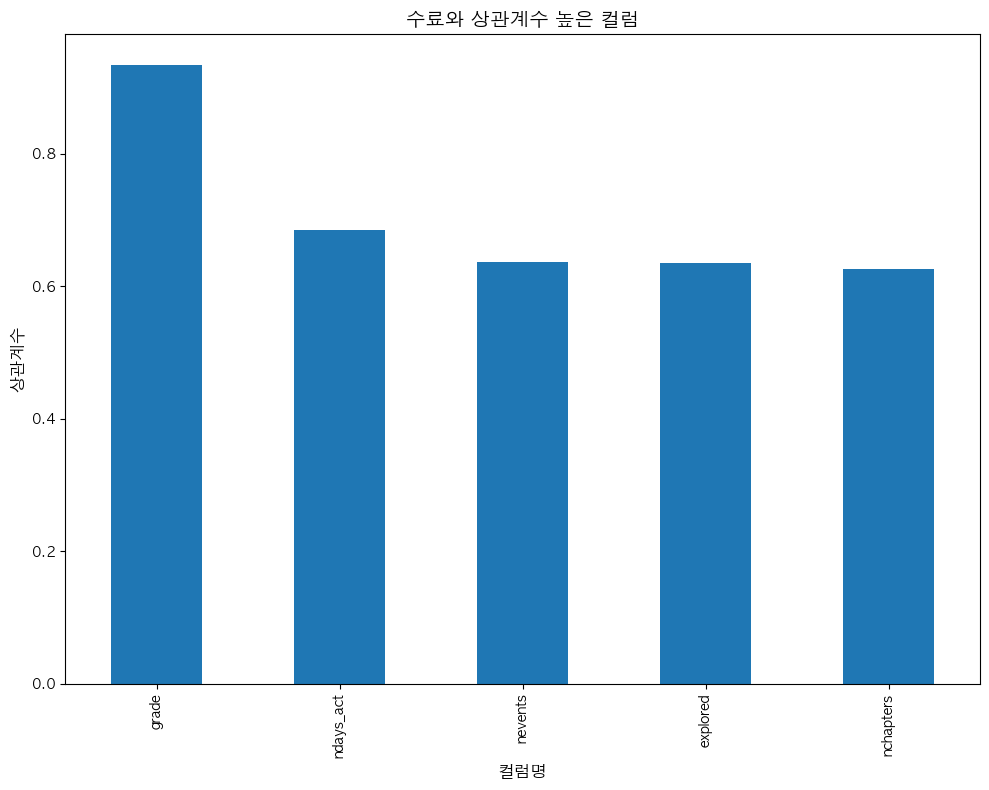

In [609]:
high_corr_certifed.plot(kind='bar', figsize=(10, 8)) 
plt.title("수료와 상관계수 높은 컬럼", fontsize=14)
plt.xlabel("컬럼명", fontsize=12)
plt.ylabel("상관계수", fontsize=12)
plt.tight_layout()
plt.show()